In [465]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import nibabel as nib

In [515]:
# load in group ICA output

gica_output = nib.load('/Users/fei/Desktop/Harris_Lab/dFNC/FPI_RS_share/ICA/all/all_mean_component_ica_s_all_.nii')
# gica_output = nib.load('/Users/fei/Desktop/Harris_Lab/dFNC/FPI_RS_share/ICA/bin_all_5.2/bin_all_mean_component_ica_s_all_.nii')
gica_data = gica_output.get_fdata()
print(gica_data.shape)
num_comps = gica_data.shape[3]
print(num_comps)

(96, 96, 25, 23)
23


In [517]:
z_scored_gica = np.zeros(gica_data.shape)
z_scored_gica.shape

(96, 96, 25, 23)

In [519]:
for i in range(num_comps):
    flattened = gica_data[:, :, :, i].flatten()
    mean = np.mean(flattened)
    std = np.std(flattened)
    z_scored_gica[:, :, :, i] = (gica_data[:, :, :, i] - mean) / std

In [521]:
# load in z-scored gRAICAR outputs

wkdir = '/Users/fei/Desktop/Harris_Lab/dFNC/FPI_RS_share/gRAICAR/FPI_All/output/z_scored_compMaps'
z_scored_paths = sorted(os.listdir(wkdir))
z_scored_gRAICAR = []
comp_nums = []

for path in z_scored_paths:
    comp = nib.load(os.path.join(wkdir, path))
    z_scored_gRAICAR.append(comp.get_fdata())
    num_label = re.findall(r'\d+', path)
    comp_nums.append(int(num_label[0]))

len(z_scored_gRAICAR)

23

(array([1.500000e+01, 7.000000e+01, 4.940000e+02, 1.730100e+04,
        5.274086e+06, 3.707000e+03, 2.100000e+03, 1.200000e+03,
        2.190000e+02, 8.000000e+00]),
 array([-47.41212082, -36.30523529, -25.19834976, -14.09146423,
         -2.9845787 ,   8.12230682,  19.22919235,  30.33607788,
         41.44296341,  52.54984894,  63.65673447]),
 <BarContainer object of 10 artists>)

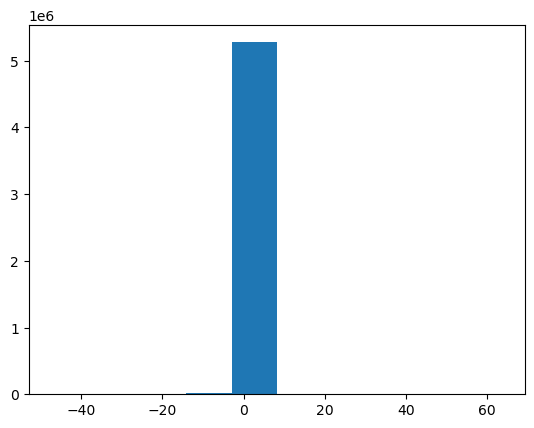

In [564]:
plt.hist(np.concatenate(z_scored_gRAICAR).flatten())

In [523]:
mask = nib.load('/Users/fei/Desktop/Harris_Lab/dFNC/FPI_RS_share/gRAICAR/FPI_All/output/ICA_mask_5.2.nii')
mask_data = mask.get_fdata()
num_good_voxels = np.sum(mask_data[:, :, :, 0])
print(mask_data.shape)
print(num_good_voxels)

(96, 96, 25, 450)
7515.0


In [524]:
multiplier = mask_data[:, :, :, :num_comps]

z_scored_gica = z_scored_gica * multiplier
z_scored_gica.shape

(96, 96, 25, 23)

In [525]:
# # to confirm that non-relevant voxels don't have nonzero contributions

# sample = mask_data[:, :, :, 0]
# print(sample.shape)
# print(np.sum(sample))
# count = 0
# for index, value in np.ndenumerate(sample):
#     if value == 1 and gica_data[index[0], index[1], index[2], 2] > 0:
#         count += 1

# print(count)
# print(np.sum(gica_data[:, :, :, 2] > 0))

In [526]:
# the gRAICAR results are z-score normalized across the entire brain, so the same should apply to the group ICA results

In [549]:
# https://www.statology.org/percentile-to-z-score-calculator/

dice_coeffs = np.zeros((num_comps, num_comps))

for i in range(num_comps):
    for j in range(num_comps):
        gica_indexes_raw = np.where(z_scored_gica[:, :, :, i] > 5.2)
        gica_indexes = set(zip(gica_indexes_raw[0], gica_indexes_raw[1], gica_indexes_raw[2]))
        gRAICAR_indexes_raw = np.where(z_scored_gRAICAR[j] > 5.2)
        gRAICAR_indexes = set(zip(gRAICAR_indexes_raw[0], gRAICAR_indexes_raw[1], gRAICAR_indexes_raw[2]))

        shared = gica_indexes.intersection(gRAICAR_indexes)
        dice_coeffs[i, j] = (2 * len(shared)) / (len(gica_indexes) + len(gRAICAR_indexes))

print(dice_coeffs)

[[0.         0.         0.         0.         0.         0.
  0.         0.47619048 0.         0.         0.         0.
  0.         0.         0.01503759 0.         0.         0.00268456
  0.         0.         0.         0.         0.00479042]
 [0.01646091 0.         0.         0.         0.35664336 0.00363636
  0.02008032 0.         0.         0.         0.         0.
  0.00518135 0.         0.00386847 0.00328407 0.         0.00273973
  0.         0.02255639 0.         0.10379242 0.00487805]
 [0.00398406 0.00393701 0.00646204 0.02360877 0.00340136 0.01060071
  0.0155642  0.04753199 0.01310044 0.26459144 0.         0.0037594
  0.         0.         0.01125704 0.0288     0.00692042 0.01072386
  0.05019305 0.02457002 0.03883495 0.02357564 0.01196172]
 [0.01395349 0.00458716 0.12797075 0.03454894 0.         0.03643725
  0.         0.00421053 0.00518135 0.         0.         0.
  0.01212121 0.00374532 0.01735358 0.04701627 0.         0.01780415
  0.0044843  0.         0.01232666 0.008456

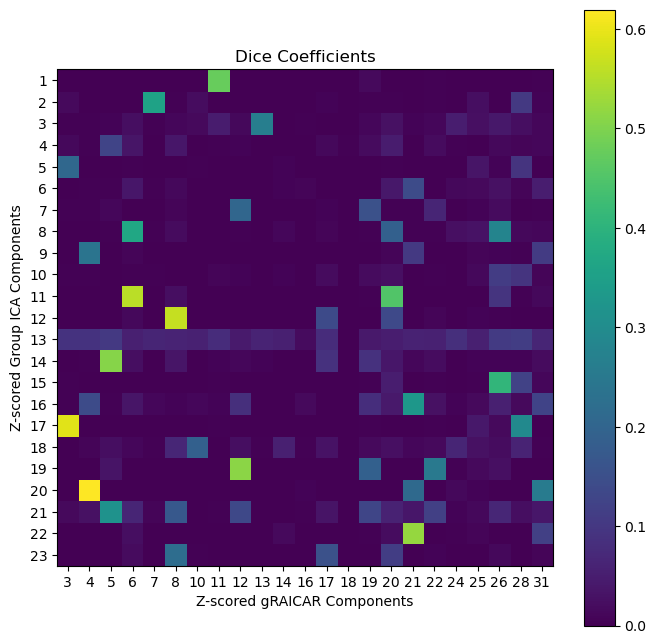

In [550]:
plt.figure(figsize=(8, 8))
heatmap = plt.imshow(dice_coeffs, cmap='viridis')

plt.xticks(range(num_comps), comp_nums)
plt.yticks(range(num_comps), range(1, num_comps+1))

plt.title("Dice Coefficients")
plt.xlabel("Z-scored gRAICAR Components")
plt.ylabel("Z-scored Group ICA Components")

cbar = plt.colorbar(heatmap)
plt.show()

In [497]:
for index, value in np.ndenumerate(dice_coeffs):
    if value > 0.4:
        print(tuple([index[0]+1, comp_nums[index[1]]]))

(11, 6)
(12, 8)
(17, 3)
(20, 4)


In [155]:
# # load in original gRAICAR outputs

# wkdir = '/Users/fei/Desktop/Harris_Lab/dFNC/FPI_RS_share/gRAICAR/FPI_All/output/compMaps'
# paths = sorted(os.listdir(wkdir))
# gRAICAR = []

# for i in range(len(paths)):
#     if i+1 in comp_nums:
#         comp = nib.load(os.path.join(wkdir, paths[i]))
#         gRAICAR.append(comp.get_fdata())

# len(gRAICAR)

23

In [222]:
# dice_coeffs_ = np.zeros((num_comps, num_comps))

# for i in range(num_comps):
#     for j in range(num_comps):
#         gica_indexes_raw = np.where(gica_data[:, :, :, i] > 0)
#         gica_indexes = set(zip(gica_indexes_raw[0], gica_indexes_raw[1], gica_indexes_raw[2]))
#         gRAICAR_indexes_raw = np.where(gRAICAR[j] > 0)
#         gRAICAR_indexes = set(zip(gRAICAR_indexes_raw[0], gRAICAR_indexes_raw[1], gRAICAR_indexes_raw[2]))

#         shared = gica_indexes.intersection(gRAICAR_indexes)
#         dice_coeffs_[i, j] = (2 * len(shared)) / (len(gica_indexes) + len(gRAICAR_indexes))

# print(dice_coeffs_)

[[0.14733458 0.13296089 0.20770202 0.20875825 0.10582785 0.16940318
  0.11039089 0.09685598 0.13914767 0.11622935 0.11243743 0.09974116
  0.10109495 0.10609736 0.11175198 0.13483498 0.16633663 0.12110092
  0.10960468 0.1129093  0.15992647 0.140801   0.14376031]
 [0.1777669  0.18214195 0.24211424 0.25454545 0.12713387 0.22206304
  0.14038956 0.12572759 0.17049666 0.1437409  0.1496844  0.12984055
  0.13622115 0.13651668 0.14435605 0.1782325  0.21479585 0.15277031
  0.14541995 0.15260755 0.20235499 0.18003856 0.18408286]
 [0.1751129  0.14662145 0.23794212 0.25425146 0.1405604  0.19706601
  0.13847305 0.10578985 0.16874292 0.13115969 0.12924546 0.1140873
  0.12803468 0.11839652 0.13317784 0.17092988 0.19554827 0.14554374
  0.13526171 0.14226654 0.18374871 0.16854778 0.17505645]
 [0.13945857 0.13584475 0.18822768 0.18293432 0.10335404 0.17920766
  0.09930209 0.09462254 0.13121352 0.10574078 0.08440797 0.08497989
  0.1025641  0.08744064 0.09095319 0.13487415 0.15298828 0.10586389
  0.1087866

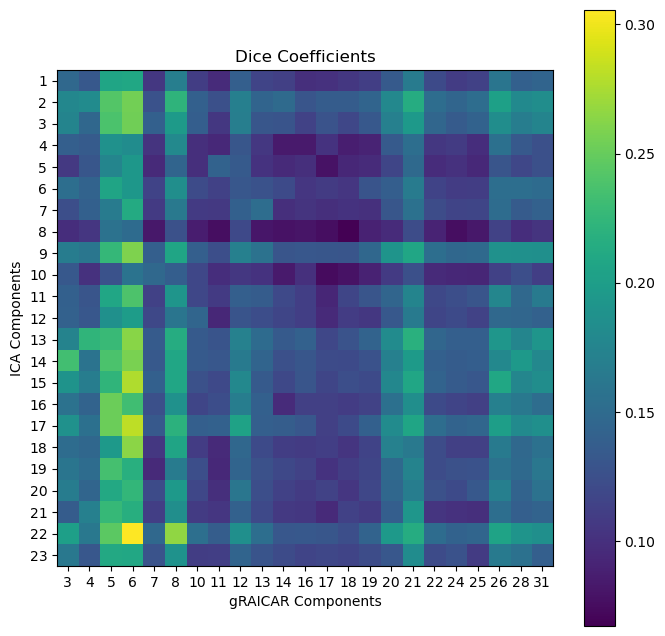

In [223]:
# plt.figure(figsize=(8, 8))
# heatmap = plt.imshow(dice_coeffs_, cmap='viridis')

# plt.xticks(range(num_comps), comp_nums)
# plt.yticks(range(num_comps), range(1, num_comps+1))

# plt.title("Dice Coefficients")
# plt.xlabel("gRAICAR Components")
# plt.ylabel("ICA Components")

# cbar = plt.colorbar(heatmap)
# plt.show()